In [7]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import ast
import pandas as pd

In [10]:
dt_errores = pd.read_parquet('..//resultados_prueba2.parquet')

In [11]:
print(dt_errores.sort_values('error',ascending=True).head(5))

top1p = (
    dt_errores
    .sort_values('error', ascending=True)
    .head( int(dt_errores.shape[0] * 0.01) )
)

top1p.groupby(['modelo', 'covariables'], as_index=False).agg(
    m_error=('error', 'mean'), sd_error = ('error', 'std'), n = ('error', 'count')
).sort_values('m_error', ascending=True)

     modelo covariables                                                cov  \
39       D6          M1  [1.632005839768912, -3.9787108646088605, 3.316...   
38       D5          M1  [1.632005839768912, -3.9787108646088605, 3.316...   
3734     D5          M1  [1.9722385995149596, 0.9278226554160363, -3.71...   
8982     D3          M1  [1.90047059163446, 4.2580128558021695, -0.2040...   
8984     D5          M1  [1.90047059163446, 4.2580128558021695, -0.2040...   

           phi     sigma    p_seco  p_transitorio  p_lluvioso     beta3  \
39   -0.329405  0.069341  0.265064       0.196060    0.430521  3.076801   
38   -0.329405  0.069341  0.265064       0.196060    0.430521  3.076801   
3734  0.052898  1.197481  0.927976       0.723757    0.592455  5.905963   
8982  0.063291  1.137642  0.452611       0.571881    0.530647  5.415267   
8984  0.063291  1.137642  0.452611       0.571881    0.530647  5.415267   

           rho     error  
39    0.347473  2.659752  
38    0.347473  2.667309  

,modelo,covariables,m_error,sd_error,n
14,D5,M7,3.448175,NaN,1
8,D5,M1,3.691786,0.559779,25
21,D6,M7,3.732238,NaN,1
0,D3,M1,3.833271,0.545295,22
15,D6,M1,3.863722,0.545155,22
5,D4,M1,3.868009,0.262929,9
9,D5,M2,3.878300,0.386786,14
24,D7,M3,3.885947,0.239631,2
28,D8,M1,3.906203,0.358681,14
22,D7,M1,3.910095,0.494094,18


In [12]:
dfD4_M1 = top1p[(top1p.modelo =='D4') & (top1p.covariables =='M1')]
print(dfD4_M1.info())

dfD3_M1 = top1p[(top1p.modelo =='D3') & (top1p.covariables =='M1')]
print(dfD3_M1.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9 entries, 8983 to 9193
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   modelo         9 non-null      object 
 1   covariables    9 non-null      object 
 2   cov            9 non-null      object 
 3   phi            9 non-null      float64
 4   sigma          9 non-null      float64
 5   p_seco         9 non-null      float64
 6   p_transitorio  9 non-null      float64
 7   p_lluvioso     9 non-null      float64
 8   beta3          9 non-null      float64
 9   rho            9 non-null      float64
 10  error          9 non-null      float64
dtypes: float64(8), object(3)
memory usage: 864.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 22 entries, 8982 to 13224
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   modelo         22 non-null     object 
 1   covariables  

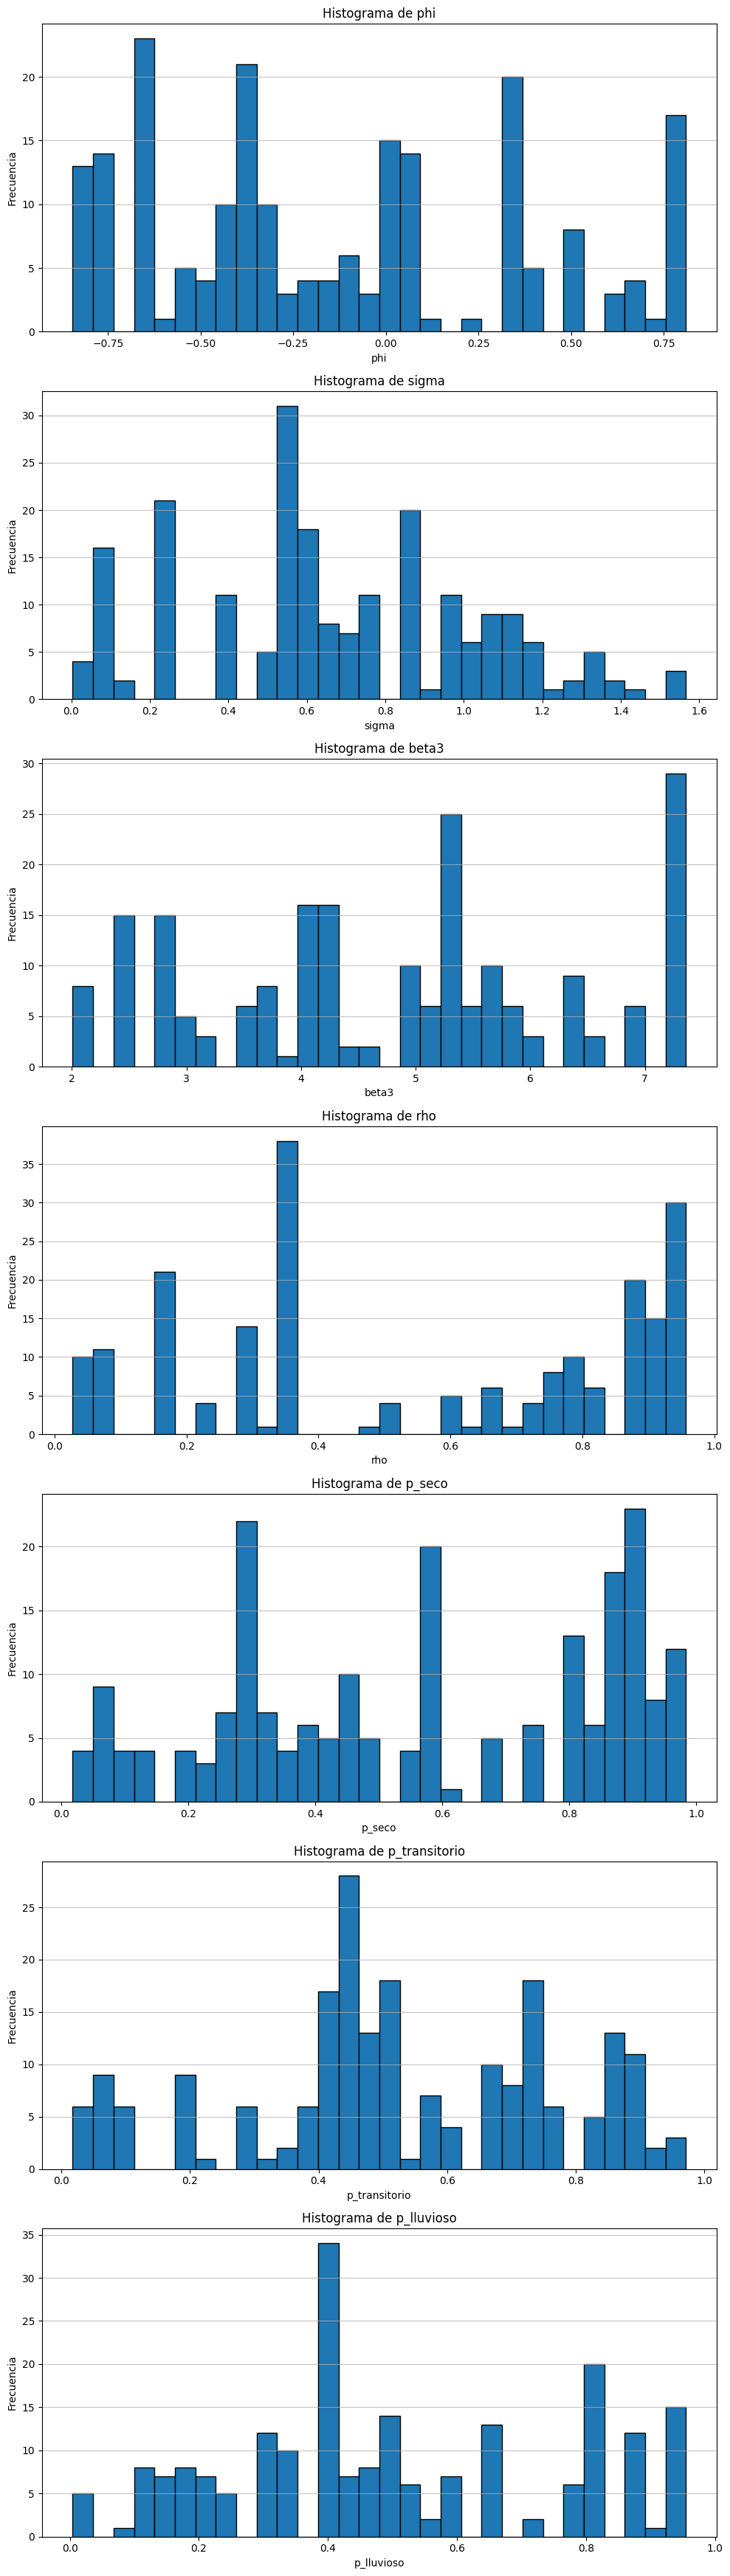

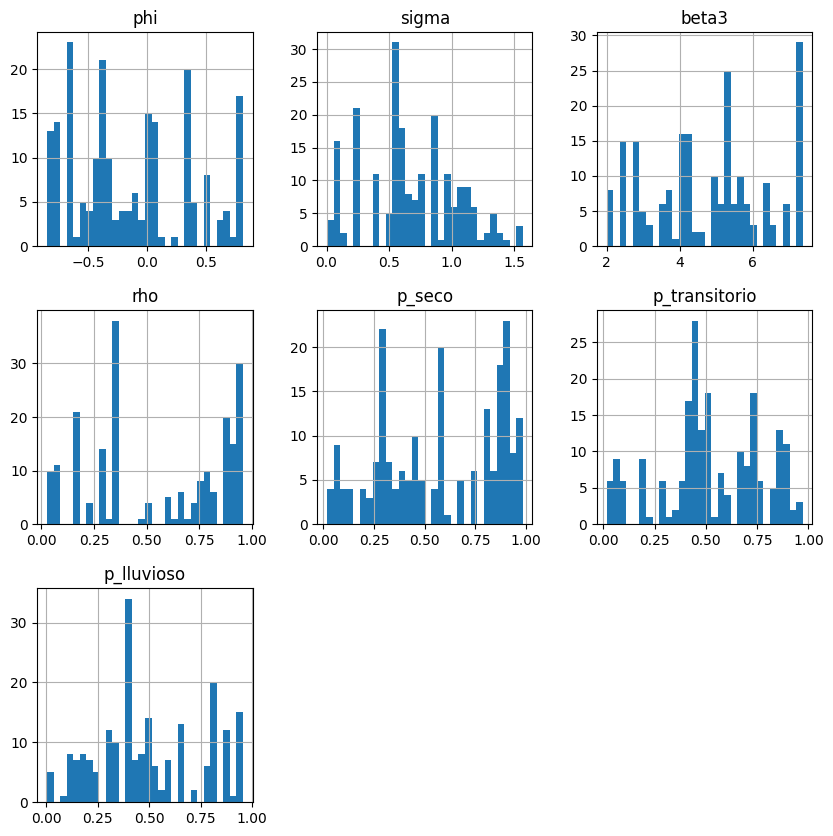

In [5]:
columnas_numericas = ['phi','sigma','beta3','rho','p_seco','p_transitorio','p_lluvioso']

fig, axs = plt.subplots(len(columnas_numericas), 1, figsize=(10, 5*len(columnas_numericas)))

for ax, col in zip(axs, columnas_numericas):
    
    if col in top1p.columns:
        ax.hist(top1p[col].dropna(), bins=30, edgecolor='black')
        ax.set_title(f'Histograma de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', alpha=0.75)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

top1p[columnas_numericas].hist(bins=30, figsize=(10,10))
plt.show()

In [13]:
revision_modelos = ['D3','D4']
revision_covariables = ['M1','M2']

subset = top1p[
    (top1p["modelo"].isin(revision_modelos)) &
    (top1p["covariables"].isin(revision_covariables))
]

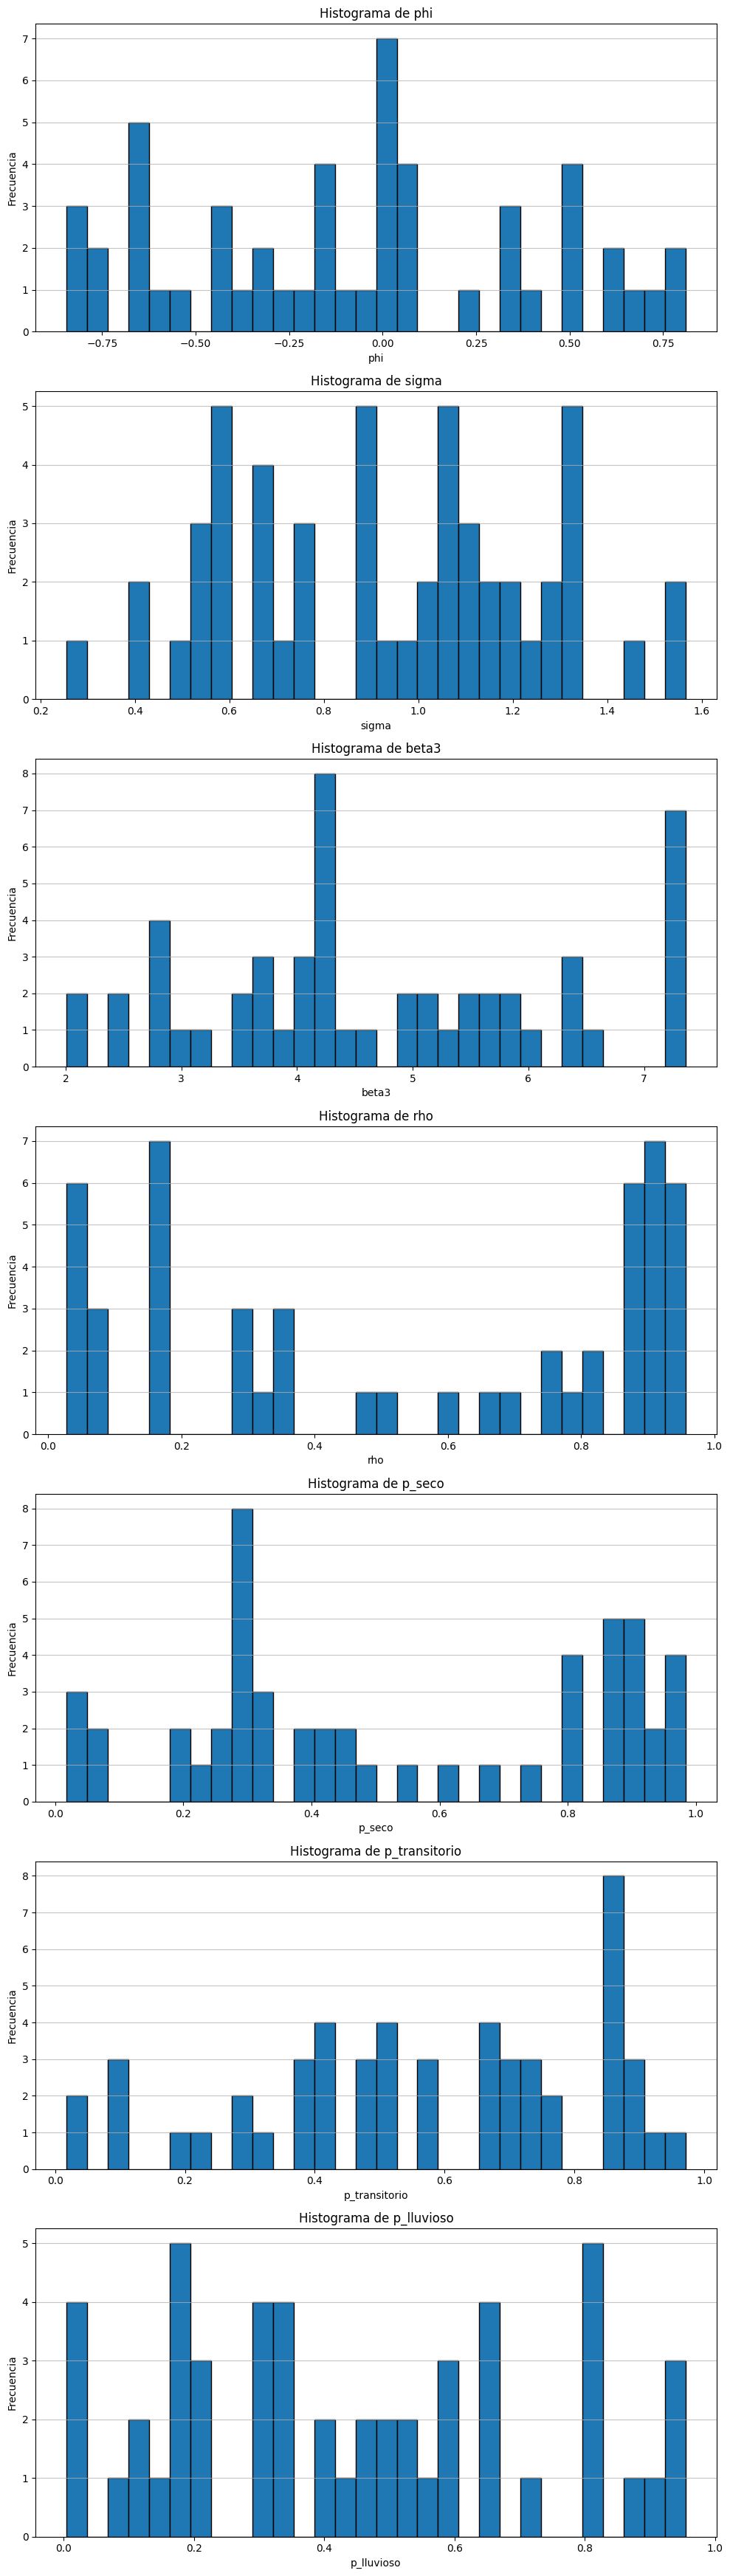

In [14]:
columnas_numericas = ['phi','sigma','beta3','rho','p_seco','p_transitorio','p_lluvioso']

fig, axs = plt.subplots(len(columnas_numericas), 1, figsize=(10, 5*len(columnas_numericas)))

for ax, col in zip(axs, columnas_numericas):

    if col in subset.columns:
        ax.hist(subset[col].dropna(), bins=30, edgecolor='black')
        ax.set_title(f'Histograma de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', alpha=0.75)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# from functools import partial
# import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import statsmodels as sm
# import statsmodels.api as sm
# import copy
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gamma, norm, multivariate_normal
from scipy.special import logit, expit
# from scipy.special import gamma, factorial
from timeit import default_timer as timer
from sklearn.preprocessing import MinMaxScaler
# importing datetime module
from datetime import datetime
import os

# Cargar datos de precipitaciones CHIRPS
datos_precipitacion = pd.read_parquet('tablas_precipitaciones.parquet')

In [13]:
datos_precipitacion['lon'] = datos_precipitacion['lon'].round(3)
datos_precipitacion['lat'] = datos_precipitacion['lat'].round(3)

In [15]:
dt_errores

,modelo,covariables,cov,phi,sigma,p_seco,p_transitorio,p_lluvioso,beta3,rho,error
0,D3,M7,"[1.632005839768912,-3.9787108646088605,3.31617...",-0.329405,0.069341,0.106025,0.278424,0.772209,3.076801,0.347473,6.006056e+07
1,D4,M7,"[1.632005839768912,-3.9787108646088605,3.31617...",-0.329405,0.069341,0.106025,0.278424,0.772209,3.076801,0.347473,6.005422e+07
2,D5,M7,"[1.632005839768912,-3.9787108646088605,3.31617...",-0.329405,0.069341,0.106025,0.278424,0.772209,3.076801,0.347473,7.852669e+07
3,D6,M7,"[1.632005839768912,-3.9787108646088605,3.31617...",-0.329405,0.069341,0.106025,0.278424,0.772209,3.076801,0.347473,7.831774e+07
4,D7,M7,"[1.632005839768912,-3.9787108646088605,3.31617...",-0.329405,0.069341,0.106025,0.278424,0.772209,3.076801,0.347473,8.833660e+07
...,...,...,...,...,...,...,...,...,...,...,...
2099995,D4,M1,"[2.5347085272983056,5.267709658364441,5.150709...",-0.392262,1.171162,0.016073,0.306465,0.752381,4.194620,0.902478,4.224456e+08
2099996,D5,M1,"[2.5347085272983056,5.267709658364441,5.150709...",-0.392262,1.171162,0.016073,0.306465,0.752381,4.194620,0.902478,6.852525e+09
2099997,D6,M1,"[2.5347085272983056,5.267709658364441,5.150709...",-0.392262,1.171162,0.016073,0.306465,0.752381,4.194620,0.902478,1.135221e+10
2099998,D7,M1,"[2.5347085272983056,5.267709658364441,5.150709...",-0.392262,1.171162,0.016073,0.306465,0.752381,4.194620,0.902478,4.632710e+09
